Bản chất của ảnh là 1 **ma trận pixels** với kích thước ***n x m***. Mỗi pixel chứa 1 giá trị để mô tả cường độ sáng (intensity) của nó.

Ảnh:
- **Ảnh xám (grey)**: intensity là UInt8 thuộc đoạn [0..255].
- **Ảnh màu (color)**: intensity là Float32 thuộc đoạn [0..1].

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# OpenCV for image processing
# Install: python -m pip install opencv-python
import cv2

In [2]:
img_1_path = './data/rose-1.jpg'
img_2_path = './data/rose-2.png'

Đối với ảnh đầu vào có màu thì sẽ có hệ màu là BGR, mà thư viện OpenCV lại xài hệ màu là RGB, vì vậy cần chuyển đổi hệ màu của ảnh gốc về hệ màu của OpenCV để có thể hiển thị chính xác màu ảnh. Để làm điều này, ta sử dụng lệnh:
```
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
```
Trong trường hợp ảnh grayscale, ta sẽ không sử dụng `cv2.cvtColor` vì nó không phù hợp và có thể gặp lỗi.

In [3]:
img_1 = cv2.imread(img_1_path, 0)  # 1 for color, 0 for grayscale

img_2 = cv2.imread(img_2_path, 1)  # 1 for color, 0 for grayscale
img_2 = cv2.cvtColor(img_2, cv2.COLOR_BGR2RGB)

In [4]:
print("Image_1 type:", end=" ")
print(type(img_1))

print("Image_2 type:", end=" ")
print(type(img_2))

Image_1 type: <class 'numpy.ndarray'>
Image_2 type: <class 'numpy.ndarray'>


`.shape` trả về tuple đại diện cho kích thước của mảng NumPy:
- Đối với ảnh grayscale: `(height, width)` (ví dụ: `(480, 640)`).
- Nếu ảnh là màu (RGB), nó sẽ là `(height, width, 3)` (3 kênh màu).

In [5]:
# Display image dimensions
print("Image_1 dimensions:", img_1.shape)

print("Image_2 dimensions:", img_2.shape)

Image_1 dimensions: (403, 428)
Image_2 dimensions: (856, 860, 3)


In [6]:
def show_image(img, title="Image", cmap=None):
    plt.figure()  # Create a new figure window for plotting
    plt.imshow(img, cmap=cmap)  # Use 'gray' colormap for grayscale images, None for RGB
    plt.axis("off")  # Hide axis
    plt.title(title)
    plt.show()

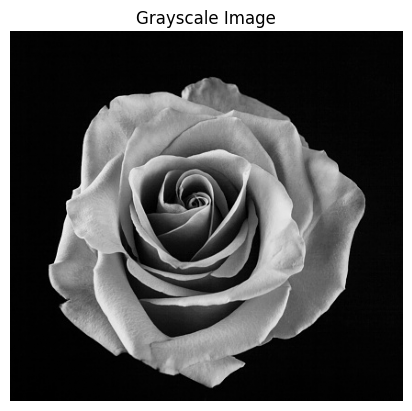

In [7]:
show_image(img_1, title="Grayscale Image", cmap="gray")

## Kênh (Channel) trong Ảnh:
Trong xử lý ảnh với OpenCV và NumPy, **Kênh (Channel)** là một chiều của mảng đại diện cho màu sắc hoặc cường độ.

- **Ảnh grayscale (xám)**: Có **1 kênh** (chỉ cường độ sáng, giá trị từ 0-255). Mảng shape: `(height, width)`.
- **Ảnh màu RGB**: Có **3 kênh** (Red, Green, Blue). Mảng shape: `(height, width, 3)`

Để hiển thị riêng 3 kênh, ta làm như sau:
- Hiển thị kênh red: `img[:, :, 0]`.
- Hiển thị kênh green: `img[:, :, 1]`.
- Hiển thị kênh blue: `img[:, :, 2]`.

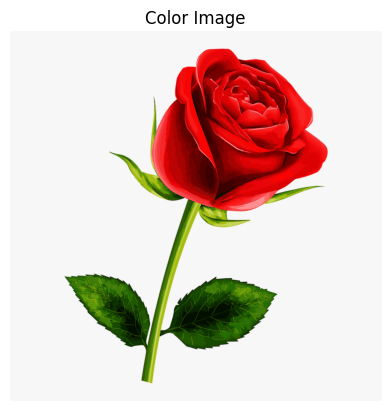

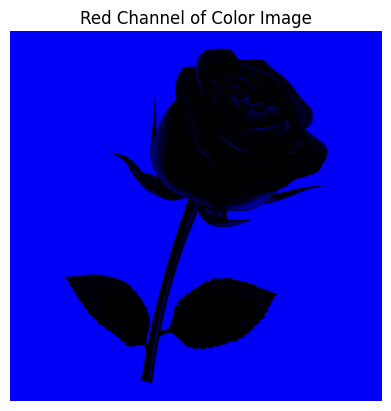

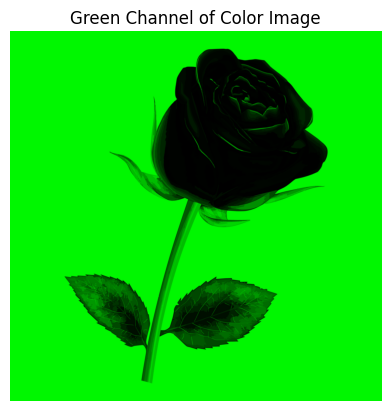

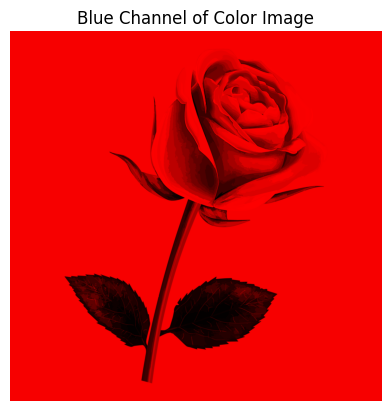

In [8]:
show_image(img_2, title="Color Image")

img_2_red_channel = img_2.copy()
img_2_red_channel[:, :, (0, 1)] = 0 # Zero out green and blue channels
show_image(img_2_red_channel, title="Red Channel of Color Image")
img_2_green_channel = img_2.copy()
img_2_green_channel[:, :, (0, 2)] = 0   # Zero out red and blue channels
show_image(img_2_green_channel, title="Green Channel of Color Image")

img_2_blue_channel = img_2.copy()
img_2_blue_channel[:, :, (1, 2)] = 0    # Zero out red and green channels
show_image(img_2_blue_channel, title="Blue Channel of Color Image")

## Point processing

#### Linear transformation:

Math:
- $g(x,y) = a \times f(x,y) + b$
- Where, $a$ and $b$: pre-defined parameters.

Application:
- General: Change the image's intensity, cause the input brighter or darker.
  - Users have to choose appropriate $a$ and $b$ (manually).
- Specific:
  - Create negative images.
  - Convert to black-white image.

#### Logarithmic transformation:

Math:
- $g(x,y) = a \times log[1 + f(x,y)] + b$
- Where, $a$ and $b$: pre-defined parameters.

Logarithmic function:
- a large value $(x)$ → mapped to a smaller value ($log_2(x)$).
- a large distance between two intensities in the input image → mapped to a smaller distance in the output.

Application:
- Input image:
  - have some regions with too dark intensities (**near 0**).
  - have some regions with too bright intensities (**near 255**).
- Requirement:
  - Make dark regions brighter while keeping the intensity in bright regions lower than 255.
  - Or, make bright regions darker while keeping the intensity in dark regions lower than 0.
- Solution: use logarithmic transformation.
- Often case:
  - Should use logarithmic transformation to enhance the result of FFT before displaying.

#### Exponential transformation

Math:
- $g(x,y) = a \times e^{f(x,y)} + b$
- Where, $a$ and $b$: pre-defined parameters.

Exponential function:
- a small value ($x$) → mapped to a larger value $e^x$.
- a small distance between two intensities in the input → mapped to a larger distance in the output image.

Application:
- map small differences between two intensities in the input to a larger differences in the output image (**contrast input images**)

#### Power-law transformation

Math:
- $g(x,y) = a \times f(x,y)^\gamma + b$
- Where, $a$ and $b$: pre-defined parameters.

Exponential function:
- Depend on $\gamma$, power-law transformation can be either:
  
  ❶ **linear transformation**: for $\gamma = 1$

  ❷ **log transformation**: for $\gamma < 1$

  ❸ **inverse-log transformation**: for $\gamma > 1$

## Histogram

[Tài liệu về Histogram](Histogram.md)

#### Vẽ Histogram

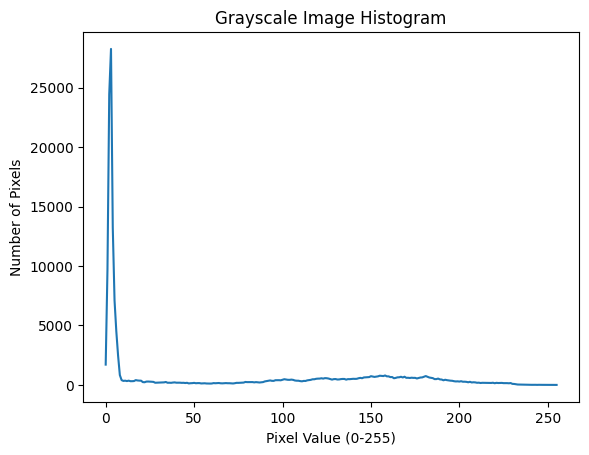

In [9]:
# Tính toán histogram
# [img]: ảnh nguồn, [0]: kênh màu, None: không dùng mask
# [256]: số lượng bin (mức giá trị), [0, 256]: dải giá trị
hist = cv2.calcHist([img_1], [0], None, [256], [0, 256])

# Vẽ biểu đồ
def show_histogram(
    hist,
    title="Image Histogram",
    xlabel="Pixel Value (0-255)",
    ylabel="Number of Pixels",
):
    plt.plot(hist)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

show_histogram(hist, title="Grayscale Image Histogram")

#### Phân tích độ phơi sáng (Exposure Analysis)

Ứng dụng này giúp ta kiểm tra xem ảnh có bị quá tối, quá sáng hay có độ tương phản thấp hay không bằng cách quan sát sự phân bố của các cột giá trị.
- Cách thực hiện: Tính Histogram và kiểm tra xem các đỉnh tập trung ở đâu.
- Ví dụ minh họa:

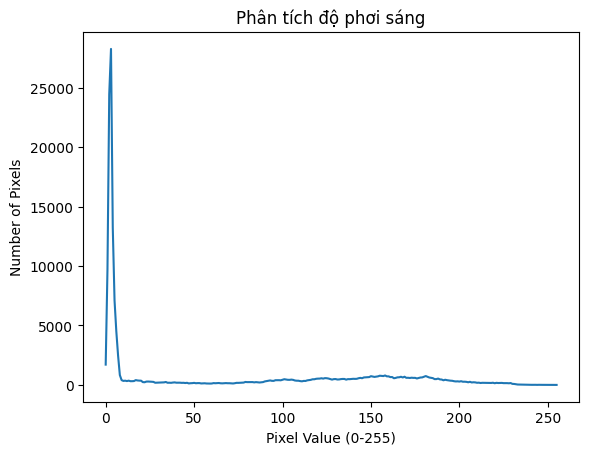

In [10]:
# import cv2
# import matplotlib.pyplot as plt


def analyze_exposure(image_path):
    img = cv2.imread(image_path, 0)
    hist = cv2.calcHist([img], [0], None, [256], [0, 256])

    show_histogram(hist, title="Phân tích độ phơi sáng")


# Nếu đỉnh tập trung bên trái (< 50): Ảnh thiếu sáng
# Nếu đỉnh tập trung bên phải (> 200): Ảnh thừa sáng

analyze_exposure(img_1_path)
# analyze_exposure(img_2_path)

#### Cân bằng Histogram (Histogram Equalization)

Đây là kỹ thuật mạnh mẽ nhất để cải thiện chất lượng hình ảnh bị mờ hoặc tối do ánh sáng kém. Nó "kéo dãn" các giá trị pixel bị dồn cục ra toàn bộ dải 0-255.
- Cách thực hiện: Sử dụng hàm `cv2.equalizeHist()` cho ảnh xám hoặc CLAHE cho ảnh màu.
- Ví dụ minh họa:

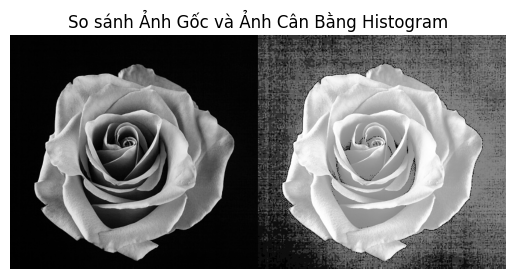

In [11]:
# import cv2
# import numpy as np

# img_1 = cv2.imread("./data/rose-1.jpg", 0)

# Cân bằng Histogram tiêu chuẩn
equ = cv2.equalizeHist(img_1)

# Hiển thị kết quả (Gộp ảnh gốc và ảnh đã xử lý để so sánh)
res = np.hstack((img_1, equ))
show_image(res, title="So sánh Ảnh Gốc và Ảnh Cân Bằng Histogram", cmap="gray")

#### Tách ngưỡng (Thresholding) bằng phương pháp Otsu

Trong xử lý ảnh, ta thường muốn tách vật thể (đen) ra khỏi nền (trắng). Nếu Histogram có 2 đỉnh rõ rệt (Bimodal), thuật toán Otsu sẽ tự động tìm "điểm thắt nút" tốt nhất để cắt.
- Cách thực hiện: Sử dụng `cv2.threshold` với cờ `cv2.THRESH_OTSU`.
- Ví dụ minh họa:

Ngưỡng tối ưu mà máy tính tìm được là: 79.0


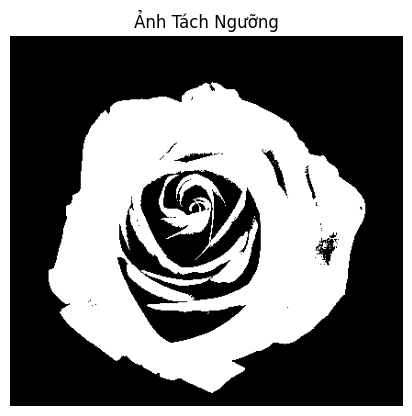

In [12]:
# import cv2

# img_1 = cv2.imread('./data/rose-1.jpg', 0)

# Tự động tìm ngưỡng tối ưu bằng Otsu
ret, thresh = cv2.threshold(img_1, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print(f"Ngưỡng tối ưu mà máy tính tìm được là: {ret}")
show_image(thresh, title='Ảnh Tách Ngưỡng', cmap='gray')

#### Nhận dạng & So sánh ảnh (Histogram Comparison)

Thay vì so sánh từng pixel (rất chậm và nhạy cảm với dịch chuyển), ta so sánh "phong cách màu sắc" của hai ảnh thông qua Histogram.
- Cách thực hiện: Tính Histogram cho cả 2 ảnh, chuẩn hóa chúng và dùng hàm `cv2.compareHist()`.
  - Phương pháp Correlation: Đo độ tương đồng tuyến tính giữa hai histogram. Giá trị:
    - 1.0: Hai histogram giống hệt nhau (tương đồng hoàn toàn).
    - 0.0: Không tương đồng.
    - -1.0: Ngược lại hoàn toàn.
  - Bạn dùng kênh H (Hue) và S (Saturation) của hệ HSV, phù hợp để so sánh màu sắc (không nhạy với độ sáng như RGB).
  - Histogram được chuẩn hóa về [0, 1], đảm bảo so sánh công bằng.
- Ví dụ minh họa:

In [ ]:
# import cv2

# Phải đọc ảnh dạng màu để ảnh grayscale vì:
# - Không mất thông tin màu
# - Không lỗi khi chuyển màu bằng `cv2.cvtColor`
img_1 = cv2.imread('./data/rose-1.jpg', 1)
img_2 = cv2.imread('./data/rose-2.png', 1)

# Chuyển sang hệ màu HSV (thường dùng để so sánh màu tốt hơn RGB)
hsv_1 = cv2.cvtColor(img_1, cv2.COLOR_BGR2HSV)
hsv_2 = cv2.cvtColor(img_2, cv2.COLOR_BGR2HSV)

# Tính Histogram cho kênh màu H (Hue) và S (Saturation)
hist1 = cv2.calcHist([hsv_1], [0, 1], None, [180, 256], [0, 180, 0, 256])
hist2 = cv2.calcHist([hsv_2], [0, 1], None, [180, 256], [0, 180, 0, 256])

# Chuẩn hóa
cv2.normalize(hist1, hist1, 0, 1, cv2.NORM_MINMAX)
cv2.normalize(hist2, hist2, 0, 1, cv2.NORM_MINMAX)

# So sánh bằng phương pháp Correlation
# Trong ví dụ này, độ tương đồng cao vì hai ảnh rất giống nhau (đều là hoa hồng).
similarity = cv2.compareHist(hist1, hist2, cv2.HISTCMP_CORREL)
print(f"Độ tương đồng: {similarity * 100:.2f}%")


Độ tương đồng: 99.82%
